In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("yield_df.csv")

df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB


In [4]:
df.isnull().sum()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [5]:
df = df.drop(columns=['Unnamed: 0'])

df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [6]:
X = df.drop(columns=['hg/ha_yield'])
y = df['hg/ha_yield']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

Target:
hg/ha_yield


In [7]:
categorical_features = ['Area', 'Item']

numerical_features = [
    'Year',
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes',
    'avg_temp'
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Area', 'Item']
Numerical features: ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numerical', 'passthrough', numerical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (22593, 6)
Testing data: (5649, 6)


In [10]:
model_pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("End-to-end ML pipeline created successfully!")

End-to-end ML pipeline created successfully!


In [11]:
model_pipeline.fit(X_train, y_train)

print("End-to-end ML pipeline trained successfully!")

End-to-end ML pipeline trained successfully!


In [12]:
y_pred = model_pipeline.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[ 70961.5   24360.64  49008.01 163303.94  56065.67  26212.95  30692.22
 109805.73 237555.11  46007.02]


In [13]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Pipeline Evaluation Results")
print("---------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Pipeline Evaluation Results
---------------------------
MAE  : 3466.65
RMSE : 9467.51
R²   : 0.9876


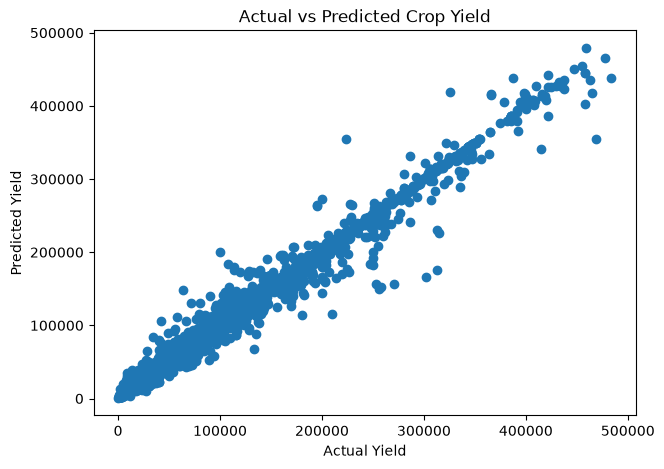

In [14]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")

plt.show()

In [15]:
model = model_pipeline.named_steps['model']
preprocessor_fitted = model_pipeline.named_steps['preprocessing']

feature_names = preprocessor_fitted.get_feature_names_out()

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
104,categorical__Item_Potatoes,0.369278
101,categorical__Item_Cassava,0.102436
108,categorical__Item_Sweet potatoes,0.086198
113,numerical__pesticides_tonnes,0.070112
42,categorical__Area_India,0.058317
112,numerical__average_rain_fall_mm_per_year,0.044208
114,numerical__avg_temp,0.041791
111,numerical__Year,0.033028
110,categorical__Item_Yams,0.027544
97,categorical__Area_United Kingdom,0.017039


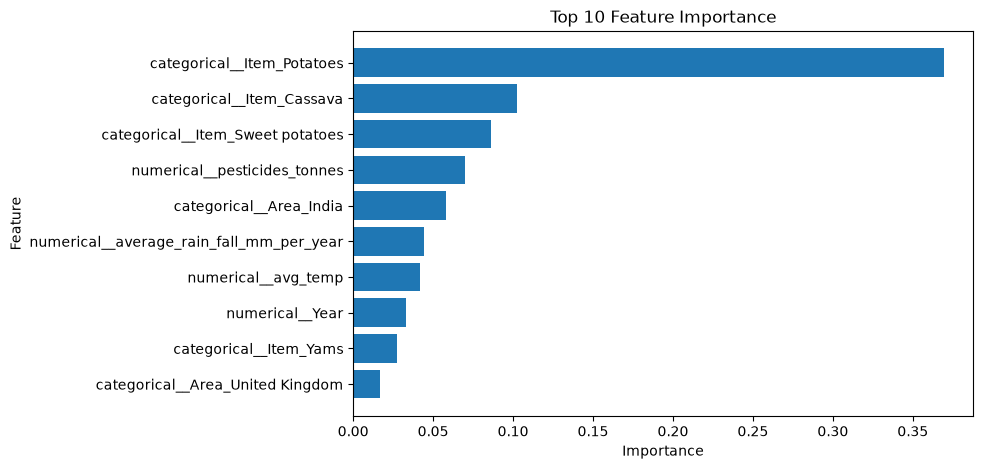

In [16]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## Conclusion

An end-to-end machine learning pipeline was developed to predict crop yield using agricultural and environmental data. The pipeline included data preprocessing, categorical encoding, train-test splitting, Random Forest Regression, prediction, and model evaluation using MAE, RMSE, and R² score. Feature importance analysis was also performed to identify the features that contributed most to the model predictions.
